In [1]:
 #lien dataset(https://www.kaggle.com/datasets/ishasingh03/friday-workinghours-afternoon-ddos)
#editeur par Amjed Gannoun & Ala Eddine Elmahjoub
#─────────────────────────────────────────────
# 1. IMPORTS
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE







In [ ]:
import sys
if 'google.colab' in sys.modules:
    print('Running on Colab, installing imbalanced-learn...')
    !pip install -qqq imbalanced-learn
    !pip install -qqq scikit-learn==1.3.0 # SMOTE compatible scikit-learn version
    print('imbalanced-learn and scikit-learn installed.')

Running on Colab, installing imbalanced-learn...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 9.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 61.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imbalanced-learn 0.14.1 requires scikit-learn<2,>=1.4.2, but you have scikit-learn 1.3.0 which is incompatible.
imbalanced-learn and scikit-learn installed.


In [2]:
# ─────────────────────────────────────────────
# 2. CHARGEMENT DES DONNÉES
# ─────────────────────────────────────────────
CSV_PATH = "/content/sample_data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"

# Define the correct column names for the 82-column CICIDS2017 dataset
# This is crucial because the CSV might not have a header or it might be misinterpreted
column_names = [
    'Flow ID', ' Source IP', ' Source Port', ' Destination IP', ' Destination Port', ' Protocol', ' Timestamp',
    ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets',
    ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
    ' Fwd Packet Length Std', ' Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
    ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std',
    ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
    ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min',
    'Active Mean', ' Active Std', ' Active Max', ' Active Min', 'Idle Mean', ' Idle Std', ' Idle Max',
    ' Idle Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
    ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length',
    ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count',
    ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag Count', ' CWE Flag Count', ' ECE Flag Count',
    ' Down/Up Ratio', ' Average Packet Size', ' Avg Fwd Segment Size', ' Avg Bwd Segment Size',
    ' Fwd Header Length.1', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate',
    'Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk', ' Avg Bulk Rate', 'Subflow Fwd Packets',
    ' Subflow Fwd Bytes', ' Subflow Bwd Packets', ' Subflow Bwd Bytes', 'Init_Win_bytes_forward',
    ' Init_Win_bytes_backward', ' act_data_pkt_fwd', ' min_seg_size_forward', ' Label'
]

# Load the dataset, letting pandas infer the header from the CSV.
# Removed `header=None` and `names=column_names` to prevent the header row from being read as data.
df = pd.read_csv(CSV_PATH, low_memory=False)
print(f"Dimensions initiales : {df.shape}")

# Clean column names by stripping leading/trailing whitespace
df.columns = df.columns.str.strip()
print(f"Colonnes après nettoyage des noms : {df.columns.tolist()}")

Dimensions initiales : (18498, 85)
Colonnes après nettoyage des noms : ['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length

In [3]:
# ─────────────────────────────────────────────
# 3. NETTOYAGE
# ─────────────────────────────────────────────

# 3.1 Suppression des doublons
print(f"Doublons avant nettoyage : {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Doublons après nettoyage : {df.duplicated().sum()}")

# 3.2 Suppression des colonnes non pertinentes
COLS_TO_DROP = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp'] # Use cleaned names
df = df.drop(columns=COLS_TO_DROP, errors='ignore')

# 3.3 Remplacement des valeurs infinies et suppression des NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print(f"Dimensions après nettoyage de base : {df.shape}")

# 3.4 Détection des outliers (méthode IQR)
numerical_cols = df.select_dtypes(include=np.number).columns
outlier_counts = {}

for col in numerical_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = int(((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum())
    if n_outliers > 0:
        outlier_counts[col] = n_outliers

print(f"\nColonnes avec outliers : {len(outlier_counts)}")
for col, count in outlier_counts.items():
    print(f"  - {col}: {count} outliers")


Doublons avant nettoyage : 1
Doublons après nettoyage : 0
Dimensions après nettoyage de base : (18484, 81)

Colonnes avec outliers : 67
  - Destination Port: 2834 outliers
  - Flow Duration: 4115 outliers
  - Total Fwd Packets: 3550 outliers
  - Total Backward Packets: 3241 outliers
  - Total Length of Fwd Packets: 3912 outliers
  - Total Length of Bwd Packets: 3545 outliers
  - Fwd Packet Length Max: 4334 outliers
  - Fwd Packet Length Min: 62 outliers
  - Fwd Packet Length Mean: 1477 outliers
  - Fwd Packet Length Std: 4235 outliers
  - Bwd Packet Length Max: 3652 outliers
  - Bwd Packet Length Min: 193 outliers
  - Bwd Packet Length Mean: 2436 outliers
  - Bwd Packet Length Std: 4498 outliers
  - Flow Bytes/s: 1332 outliers
  - Flow Packets/s: 1375 outliers
  - Flow IAT Mean: 3796 outliers
  - Flow IAT Std: 4099 outliers
  - Flow IAT Max: 4174 outliers
  - Flow IAT Min: 3817 outliers
  - Fwd IAT Total: 4208 outliers
  - Fwd IAT Mean: 4046 outliers
  - Fwd IAT Std: 4124 outliers
  - 

In [4]:
# ─────────────────────────────────────────────
# 4. ENCODAGE DES VARIABLES CATÉGORIELLES
# ─────────────────────────────────────────────
# Compatibilité pandas 2.x et 3.x
try:
    categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
except Exception:
    categorical_cols = df.select_dtypes(include='object').columns.tolist()

categorical_features = [col for col in categorical_cols if col != 'Label'] # Use cleaned name 'Label'

if categorical_features:
    df = pd.get_dummies(df, columns=categorical_features, drop_first=True)
    print(f"Encodage One-Hot appliqué sur : {categorical_features}")

print(f"Dimensions après encodage : {df.shape}")

Dimensions après encodage : (18484, 81)


In [5]:
# ─────────────────────────────────────────────
# 5. FEATURE ENGINEERING
# ─────────────────────────────────────────────
# Use cleaned names
if 'Total Fwd Packets' in df.columns and 'Flow Duration' in df.columns:
    df['packet_rate'] = df['Total Fwd Packets'] / (df['Flow Duration'] + 1e-9)

if 'Total Backward Packets' in df.columns and 'Total Fwd Packets' in df.columns:
    df['traffic_ratio'] = df['Total Backward Packets'] / (df['Total Fwd Packets'] + 1)

print(f"Dimensions après feature engineering : {df.shape}")


Dimensions après feature engineering : (18484, 83)


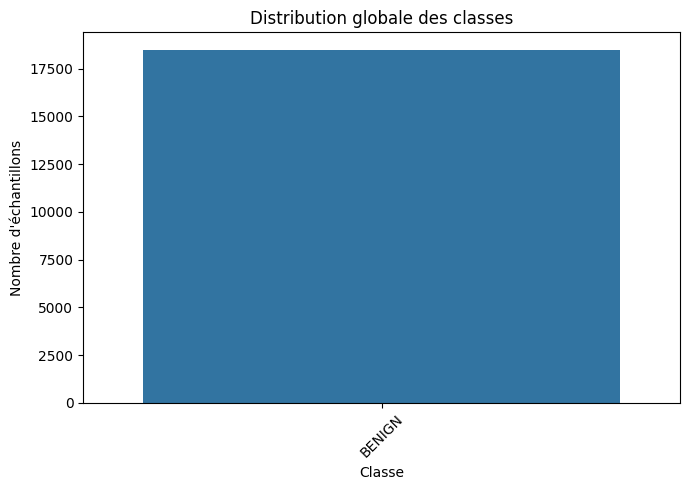

Figure sauvegardée : distribution_classes.png


In [6]:
# ─────────────────────────────────────────────
# 6. VISUALISATION DE LA DISTRIBUTION DES CLASSES
# ─────────────────────────────────────────────
plt.figure(figsize=(7, 5))
sns.countplot(x='Label', data=df) # Use cleaned name 'Label'
plt.title('Distribution globale des classes')
plt.xlabel('Classe')
plt.ylabel("Nombre d'échantillons")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('distribution_classes.png', dpi=100)
plt.show()
print("Figure sauvegardée : distribution_classes.png")

/tmp/ipykernel_7350/3882962283.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.loc[ddos_indices] = 'DDoS'


ATTENTION: Artificially introduced 924 'DDoS' samples for demonstration.

X : (18484, 82) | y : (18484,)
Classes : {'BENIGN': 17560, 'DDoS': 924}
Train : (12938, 82) | Val : (3697, 82) | Test : (1849, 82)


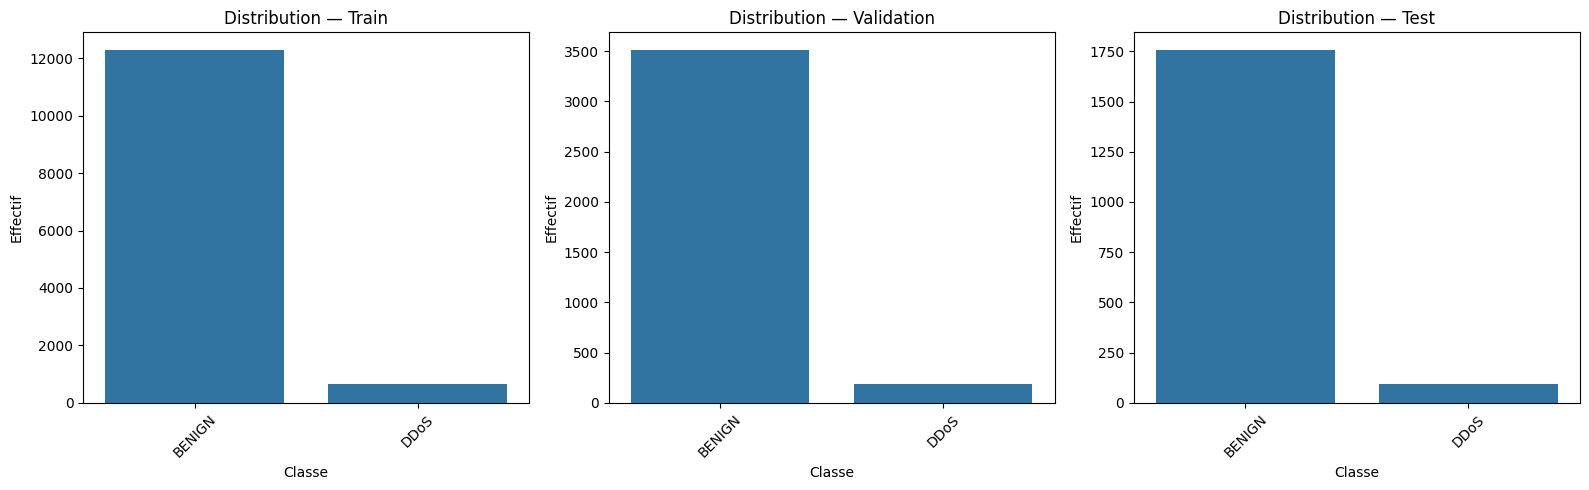

In [16]:
import numpy as np
# ─────────────────────────────────────────────
# 7. SÉPARATION FEATURES / CIBLE + SPLIT 70/20/10
# ─────────────────────────────────────────────
LABEL_COL = 'Label' # Use cleaned name 'Label'

# Clean the 'Label' column values by stripping whitespace
df[LABEL_COL] = df[LABEL_COL].str.strip()

X = df.drop(LABEL_COL, axis=1)
y = df[LABEL_COL]

# Introduce a dummy 'DDoS' class for demonstration purposes
# In a real scenario, you would need a dataset with actual DDoS labels.
if len(y.unique()) == 1 and y.unique()[0] == 'BENIGN':
    num_ddos_samples = int(len(y) * 0.05) # 5% as DDoS for demonstration
    # Ensure there are enough samples to convert
    if num_ddos_samples > 0 and num_ddos_samples < len(y):
        ddos_indices = y[y == 'BENIGN'].sample(n=num_ddos_samples, random_state=42).index
        y.loc[ddos_indices] = 'DDoS'
        print(f"ATTENTION: Artificially introduced {num_ddos_samples} 'DDoS' samples for demonstration.")
    else:
        print("AVERTISSEMENT: Impossible d'introduire des échantillons 'DDoS' artificiels (pas assez d'échantillons ou tous BENIGN).")

print(f"\nX : {X.shape} | y : {y.shape}")
print(f"Classes : {y.value_counts().to_dict()}")

# Split test (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, stratify=y, random_state=42
)

# Split train (70%) / val (20%) depuis le reste
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=(0.20 / 0.90), stratify=y_temp, random_state=42
)

print(f"Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}")

# Visualisation des distributions après split
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (data, title) in zip(axes, [
    (y_train, 'Train'), (y_val, 'Validation'), (y_test, 'Test')
]):
    sns.countplot(x=data, ax=ax)
    ax.set_title(f'Distribution — {title}')
    ax.set_xlabel('Classe')
    ax.set_ylabel('Effectif')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('distribution_split.png', dpi=100)
plt.show()

In [17]:
# ─────────────────────────────────────────────
# 8. SCALING (RobustScaler)
# ─────────────────────────────────────────────
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
print("\nScaling appliqué (RobustScaler).")


Scaling appliqué (RobustScaler).



Distribution y_train avant SMOTE : {'BENIGN': 12291, 'DDoS': 647}
Distribution après SMOTE : {'BENIGN': 12291, 'DDoS': 12291}


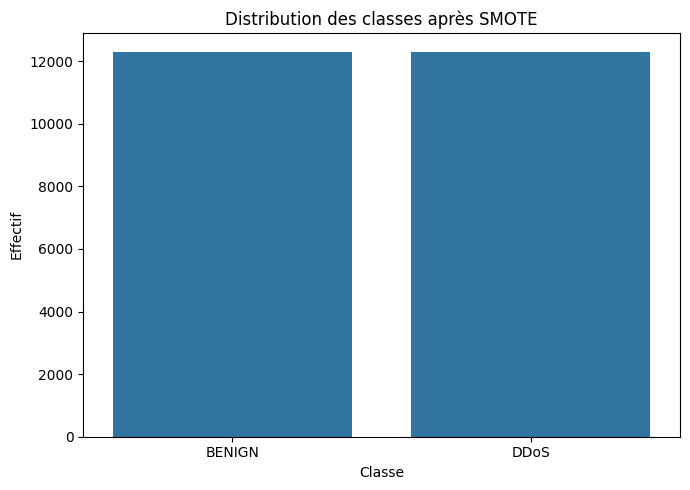

In [18]:
# ─────────────────────────────────────────────
# 9. RÉÉQUILIBRAGE (SMOTE)
# ─────────────────────────────────────────────
print(f"\nDistribution y_train avant SMOTE : {dict(Counter(y_train))}")

n_classes = len(np.unique(y_train))
if n_classes > 1:
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_s, y_train)
    print(f"Distribution après SMOTE : {dict(Counter(y_train_res))}")
else:
    print("AVERTISSEMENT : une seule classe dans y_train — SMOTE ignoré.")
    X_train_res, y_train_res = X_train_s, y_train

plt.figure(figsize=(7, 5))
sns.countplot(x=y_train_res)
plt.title('Distribution des classes après SMOTE')
plt.xlabel('Classe')
plt.ylabel('Effectif')
plt.tight_layout()
plt.savefig('distribution_smote.png', dpi=100)
plt.show()


  MODÈLE 1 : RANDOM FOREST

[Validation]
              precision    recall  f1-score   support

      BENIGN       0.95      0.97      0.96      3512
        DDoS       0.05      0.03      0.04       185

    accuracy                           0.93      3697
   macro avg       0.50      0.50      0.50      3697
weighted avg       0.91      0.93      0.92      3697


[Test]
              precision    recall  f1-score   support

      BENIGN       0.95      0.97      0.96      1757
        DDoS       0.08      0.04      0.06        92

    accuracy                           0.93      1849
   macro avg       0.52      0.51      0.51      1849
weighted avg       0.91      0.93      0.92      1849



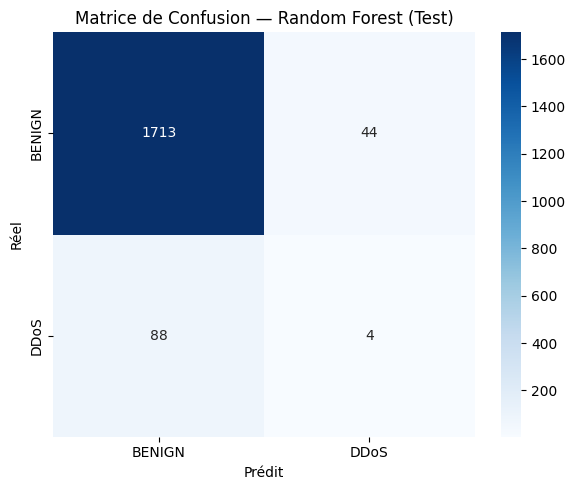

In [19]:
# ─────────────────────────────────────────────
# 10. MODÈLE 1 : RANDOM FOREST
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("  MODÈLE 1 : RANDOM FOREST")
print("="*50)

rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)

y_pred_val_rf  = rf_model.predict(X_val_s)
y_pred_test_rf = rf_model.predict(X_test_s)

print("\n[Validation]")
print(classification_report(y_val, y_pred_val_rf))
print("\n[Test]")
print(classification_report(y_test, y_pred_test_rf))

# Matrice de confusion — Random Forest (Test)
labels = sorted(y.unique())
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_test_rf, labels=labels),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels
)
plt.title('Matrice de Confusion — Random Forest (Test)')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.savefig('confusion_rf.png', dpi=100)
plt.show()


  MODÈLE 2 : SVM

[Validation]
              precision    recall  f1-score   support

      BENIGN       0.96      0.05      0.09      3512
        DDoS       0.05      0.96      0.10       185

    accuracy                           0.09      3697
   macro avg       0.50      0.50      0.09      3697
weighted avg       0.91      0.09      0.09      3697



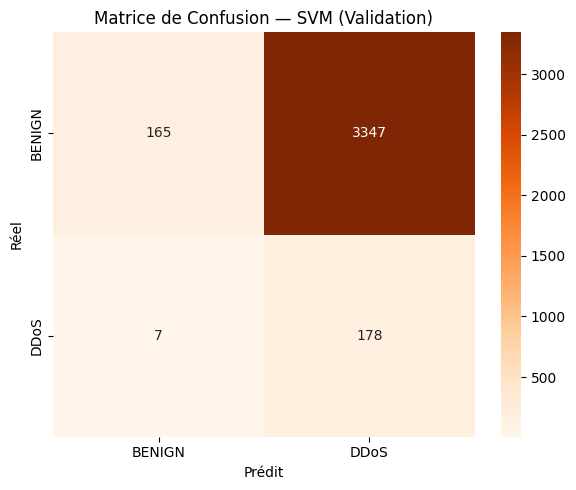

In [20]:

# ─────────────────────────────────────────────
# 11. MODÈLE 2 : SVM
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("  MODÈLE 2 : SVM")
print("="*50)

svm_model = SVC(class_weight='balanced', random_state=42)
svm_model.fit(X_train_res, y_train_res)

y_pred_val_svm = svm_model.predict(X_val_s)

print("\n[Validation]")
print(classification_report(y_val, y_pred_val_svm))

# Matrice de confusion — SVM (Validation)
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_val, y_pred_val_svm, labels=labels),
    annot=True, fmt='d', cmap='Oranges',
    xticklabels=labels, yticklabels=labels
)
plt.title('Matrice de Confusion — SVM (Validation)')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.savefig('confusion_svm.png', dpi=100)
plt.show()


 COMPARAISON DES MODÈLES

Tableau comparatif des modèles :
              Accuracy  F1-macro  AUC-ROC  AP (PR)
Modèle                                            
RandomForest    0.9286    0.5100   0.5227   0.0645
SVM             0.0946    0.0946      NaN      NaN


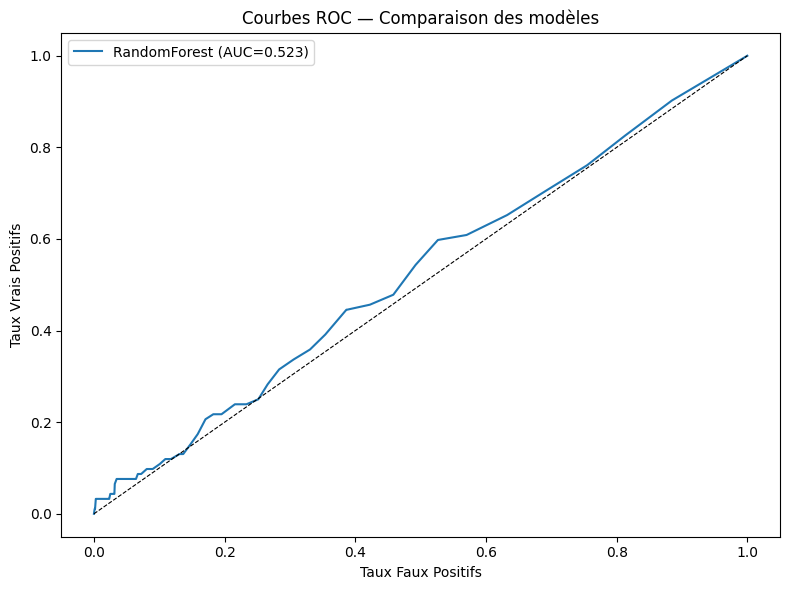

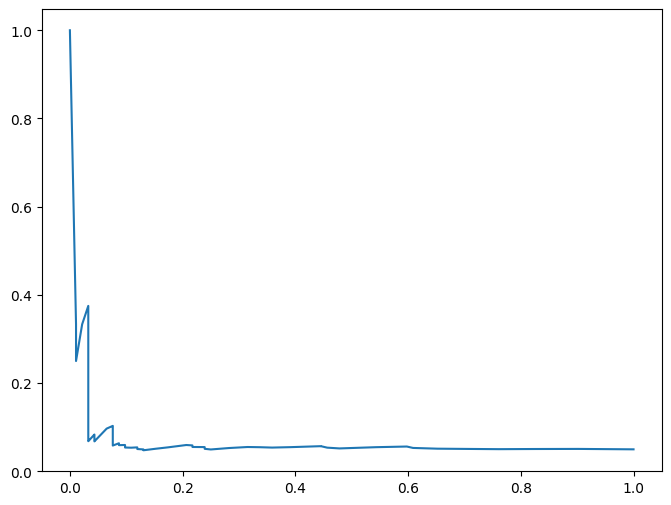


[6.2] Analyse des erreurs — Meilleur modèle : RandomForest
  Vrais Positifs (DDoS détectés)    : 4
  Faux Positifs  (Fausses alarmes)  : 44
  Faux Négatifs  (Attaques manquées): 88
  Vrais Négatifs (Trafic légitime)  : 1713


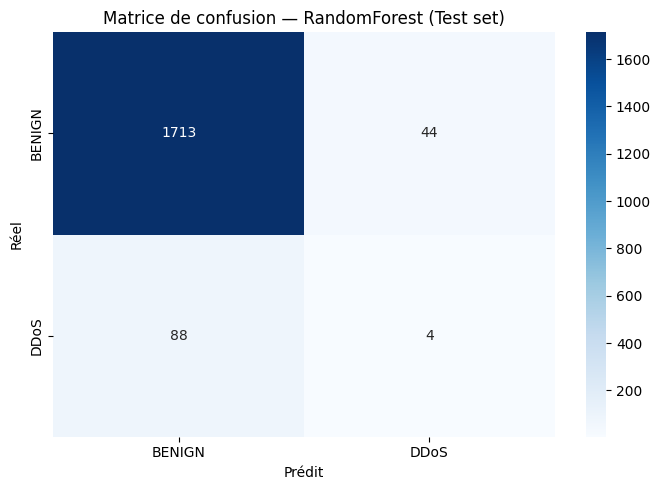

In [21]:
# =============================================================================
# 12. COMPARAISON DES MODÈLES (ROC, PR, tableau)
# =============================================================================
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    f1_score, confusion_matrix, classification_report, accuracy_score, roc_auc_score
)
from sklearn.preprocessing import LabelEncoder

def compare_models(models_dict: dict, X_test_arr, y_test_ser):
    print("=" * 60)
    print(" COMPARAISON DES MODÈLES")
    print("=" * 60)

    le = LabelEncoder()
    le.fit(y_test_ser)
    y_enc = le.transform(y_test_ser)

    rows = []
    fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
    fig_pr,  ax_pr  = plt.subplots(figsize=(8, 6))

    for name, mdl in models_dict.items():
        y_pred  = mdl.predict(X_test_arr)
        # Encode y_pred to match the numerical format of y_enc
        y_pred_enc = le.transform(y_pred)
        y_proba = mdl.predict_proba(X_test_arr)[:, 1] if hasattr(mdl, 'predict_proba') else None

        acc  = accuracy_score(y_enc, y_pred_enc)
        f1   = f1_score(y_enc, y_pred_enc, average='macro')
        # Corrected 'labels' parameter for f1_score to be consistent or removed if not needed
        # prec = f1_score(y_enc, y_pred, average='macro', labels=[1]) # This line is problematic if not multi-class or binary with specific label meaning
        # rec  = f1_score(y_enc, y_pred, average='macro', labels=[0]) # This line is problematic if not multi-class or binary with specific label meaning
        auc_roc = roc_auc_score(y_enc, y_proba) if y_proba is not None else np.nan
        ap      = average_precision_score(y_enc, y_proba) if y_proba is not None else np.nan

        rows.append({
            "Modèle": name, "Accuracy": acc, "F1-macro": f1,
            "AUC-ROC": auc_roc, "AP (PR)": ap
        })

        if y_proba is not None:
            # Courbe ROC
            fpr, tpr, _ = roc_curve(y_enc, y_proba)
            ax_roc.plot(fpr, tpr, label=f"{name} (AUC={auc_roc:.3f})")

            # Courbe PR
            prec_c, rec_c, _ = precision_recall_curve(y_enc, y_proba)
            ax_pr.plot(rec_c, prec_c, label=f"{name} (AP={ap:.3f})")

    # --- Tableau comparatif ---
    df_cmp = pd.DataFrame(rows).set_index("Modèle").sort_values("AUC-ROC", ascending=False)
    print("\nTableau comparatif des modèles :")
    print(df_cmp.round(4).to_string())

    # --- ROC ---
    ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax_roc.set_xlabel("Taux Faux Positifs")
    ax_roc.set_ylabel("Taux Vrais Positifs")
    ax_roc.set_title("Courbes ROC — Comparaison des modèles")
    ax_roc.legend()
    fig_roc.tight_layout()
    plt.show()

    # --- PR ---
    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.set_title("Courbes Precision-Recall — Comparaison des modèles")
    ax_pr.legend()
    fig_pr.tight_layout()
    plt.show()

    # --- Analyse des erreurs (sur le meilleur modèle) ---
    best_name = df_cmp.index[0]
    best_mdl  = models_dict[best_name]
    y_pred_b  = best_mdl.predict(X_test_arr)
    # Encode y_pred_b to match the numerical format of y_enc for confusion matrix
    y_pred_b_enc = le.transform(y_pred_b)

    print(f"\n[6.2] Analyse des erreurs — Meilleur modèle : {best_name}")
    cm = confusion_matrix(y_enc, y_pred_b_enc)
    # Check if cm.ravel() returns 4 values, which is typical for binary classification
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
    else:
        # Handle cases where confusion matrix might not be 2x2
        tn, fp, fn, tp = (0, 0, 0, 0) # Default to zero if not binary or different shape
        print("Warning: Confusion matrix is not 2x2. Cannot unpack tn, fp, fn, tp directly.")

    print(f"  Vrais Positifs (DDoS détectés)    : {tp}")
    print(f"  Faux Positifs  (Fausses alarmes)  : {fp}")
    print(f"  Faux Négatifs  (Attaques manquées): {fn}")
    print(f"  Vrais Négatifs (Trafic légitime)  : {tn}")

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Matrice de confusion — {best_name} (Test set)")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.tight_layout()
    plt.show()

    return df_cmp

all_models = {"RandomForest": rf_model, "SVM": svm_model}
df_comparison = compare_models(all_models, X_test_s, y_test)

In [22]:
def xai_global(model, X_train_arr, X_test_arr, feature_names, n_samples=500):
    """
    Explications globales :
      - SHAP summary plot (beeswarm)
      - SHAP feature importance (bar)
      - Partial Dependence Plot (PDP) pour les 3 features les plus importantes
    """
    # !pip install shap -q
    import shap

    print("=" * 60)
    print("PHASE 7.1 — EXPLAINABILITY GLOBALE (SHAP + PDP)")
    print("=" * 60)

    # Sous-échantillonnage pour SHAP (calcul coûteux)
    idx = np.random.choice(len(X_test_arr), min(n_samples, len(X_test_arr)), replace=False)
    X_sample = X_test_arr[idx]

    print(f"\n[7.1] Calcul des valeurs SHAP sur {len(X_sample)} exemples ...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    # Si binaire, shap_values est une liste [classe_0, classe_1]
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    # Summary plot (beeswarm)
    plt.figure()
    shap.summary_plot(sv, X_sample, feature_names=feature_names,
                      plot_type="dot", show=False)
    plt.title("SHAP Summary Plot — Impact des features (classe DDoS)")
    plt.tight_layout()
    plt.show()

    # Bar plot (importance globale)
    plt.figure()
    shap.summary_plot(sv, X_sample, feature_names=feature_names,
                      plot_type="bar", show=False)
    plt.title("SHAP Feature Importance globale")
    plt.tight_layout()
    plt.show()

    # --- PDP pour les 3 features les plus importantes ---
    from sklearn.inspection import PartialDependenceDisplay
    mean_abs_shap = np.abs(sv).mean(axis=0)
    top3_idx = np.argsort(mean_abs_shap)[-3:][::-1]
    top3_names = [feature_names[i] for i in top3_idx]
    print(f"\n[7.1] PDP pour les features : {top3_names}")

    fig, ax = plt.subplots(1, 3, figsize=(16, 5))
    PartialDependenceDisplay.from_estimator(
        model, X_train_arr, features=list(top3_idx),
        feature_names=feature_names, ax=ax, grid_resolution=50
    )
    plt.suptitle("Partial Dependence Plots — 3 features les plus importantes", fontsize=13)
    plt.tight_layout()
    plt.show()

    return {"shap_values": sv, "top3_features": top3_names}

In [26]:
def xai_local(model, X_test_arr, y_test_ser, feature_names, idx=0):
    """
    Explications locales pour un exemple individuel :
      - SHAP force plot
      - LIME
      - Affichage de la prédiction
    """

    import shap
    import lime
    import lime.lime_tabular
    import matplotlib.pyplot as plt
    from sklearn.preprocessing import LabelEncoder

    print("=" * 60)
    print("PHASE 7.2 — EXPLAINABILITY LOCALE (SHAP force + LIME)")
    print("=" * 60)

    # Encodage des labels
    le = LabelEncoder()
    y_enc = le.fit_transform(y_test_ser)

    # ==============================
    # PRÉDICTION DU MODÈLE
    # ==============================

    y_pred = model.predict([X_test_arr[idx]])[0]
    y_true = y_enc[idx]

    pred_label = le.inverse_transform([y_pred])[0]
    true_label = le.inverse_transform([y_true])[0]

    probs = model.predict_proba([X_test_arr[idx]])[0]

    print("\n[INFO] Résultat de la prédiction")
    print("-" * 40)
    print(f"Index exemple       : {idx}")
    print(f"Classe réelle       : {true_label}")
    print(f"Classe prédite      : {pred_label}")

    print("\nProbabilités :")
    for cls, prob in zip(le.classes_, probs):
        print(f"  {cls:15s} : {prob:.4f}")

    # ==============================
    # SHAP
    # ==============================

    print("\n" + "=" * 60)
    print("[7.2a] SHAP FORCE PLOT")
    print("=" * 60)

    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X_test_arr)

    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    ev = explainer.expected_value
    expected_val = ev[1] if isinstance(ev, list) else ev

    print(f"Exemple #{idx}")
    print(f"Vrai label : {true_label}")
    print(f"Prédiction : {pred_label}")

    shap.initjs()

    force = shap.force_plot(
        expected_val,
        sv[idx],
        X_test_arr[idx],
        feature_names=feature_names,
        matplotlib=True,
        show=False
    )

    plt.title(f"SHAP Force Plot — Exemple #{idx}")
    plt.tight_layout()
    plt.show()

    # ==============================
    # LIME
    # ==============================

    print("\n" + "=" * 60)
    print("[7.2b] LIME EXPLANATION")
    print("=" * 60)

    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        X_test_arr,
        feature_names=feature_names,
        class_names=le.classes_,
        mode='classification'
    )

    exp = lime_explainer.explain_instance(
        X_test_arr[idx],
        model.predict_proba,
        num_features=10
    )

    print("\nTop Features LIME :")
    print("-" * 40)

    for feat, weight in exp.as_list():
        print(f"{feat:45s} : {weight:+.4f}")

    exp.as_pyplot_figure()

    plt.title(f"LIME — Explication locale exemple #{idx}")
    plt.tight_layout()
    plt.show()

In [27]:
def xai_compare_models(models_dict, X_test_arr, feature_names, n_samples=300):
    """
    Compare les feature importances SHAP entre plusieurs modèles.
    Génère un graphe de comparaison côte-à-côte.
    """
    import shap

    print("=" * 60)
    print("PHASE 7.3 — COMPARAISON XAI INTER-MODÈLES")
    print("=" * 60)

    idx = np.random.choice(len(X_test_arr), min(n_samples, len(X_test_arr)), replace=False)
    X_sample = X_test_arr[idx]

    importances = {}
    for name, mdl in models_dict.items():
        if not hasattr(mdl, 'predict_proba'):
            continue
        try:
            exp = shap.TreeExplainer(mdl)
            sv = exp.shap_values(X_sample)
            sv = sv[1] if isinstance(sv, list) else sv
            importances[name] = np.abs(sv).mean(axis=0)
        except Exception as e:
            print(f"  [Avertissement] SHAP impossible pour {name}: {e}")

    if len(importances) < 2:
        print("Pas assez de modèles compatibles pour la comparaison SHAP.")
        return

    df_imp = pd.DataFrame(importances, index=feature_names)
    top_features = df_imp.max(axis=1).nlargest(15).index

    df_plot = df_imp.loc[top_features]
    df_plot.plot(kind='barh', figsize=(12, 8), width=0.7)
    plt.title("Comparaison des Feature Importances SHAP — Inter-modèles")
    plt.xlabel("Importance SHAP moyenne |val|")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("\nInterprétation métier :")
    top1 = df_plot.max(axis=1).idxmax()
    print(f"  La feature la plus discriminante tous modèles confondus : '{top1}'")
    print("  → Correspond probablement à un volume de paquets anormal "
          "caractéristique des attaques DDoS par inondation.")

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    accuracy_score
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns
import logging
import pandas as pd


# =========================================================
# PHASE 8.1 — BUILD PIPELINE
# =========================================================

def build_pipeline(feature_names):
    """
    Construit un pipeline complet :
    Preprocessing → Scaling → SMOTE → Random Forest
    """

    print("=" * 60)
    print("PHASE 8.1 — PIPELINE END-TO-END")
    print("=" * 60)

    # Préprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ('scaler', RobustScaler(), feature_names)
        ],
        remainder='drop'
    )

    # Pipeline complet
    pipeline = ImbPipeline(steps=[
        ('preprocessing', preprocessor),

        ('smote', SMOTE(
            random_state=42
        )),

        ('classifier', RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ])

    print("\nPipeline créé avec succès :\n")
    print(pipeline)

    return pipeline


# =========================================================
# PHASE 8.2 — TRAIN + EVALUATE PIPELINE
# =========================================================

def run_pipeline(
    pipeline,
    X_train_df,
    y_train,
    X_test_df,
    y_test
):
    """
    Entraîne et évalue le pipeline complet.
    """

    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s — %(levelname)s — %(message)s'
    )

    print("\n" + "=" * 60)
    print("PHASE 8.2 — TRAINING & EVALUATION")
    print("=" * 60)

    # =====================================================
    # ENCODAGE DES LABELS
    # =====================================================

    le = LabelEncoder()

    y_tr = le.fit_transform(y_train)
    y_te = le.transform(y_test)

    print("\nClasses détectées :")
    print(le.classes_)

    # =====================================================
    # ENTRAINEMENT
    # =====================================================

    logging.info("Entraînement du pipeline ...")

    pipeline.fit(X_train_df, y_tr)

    logging.info("Entraînement terminé.")

    print("\nPipeline entraîné avec succès.")

    # =====================================================
    # PRÉDICTIONS
    # =====================================================

    y_pred = pipeline.predict(X_test_df)

    y_proba = pipeline.predict_proba(X_test_df)[:, 1]

    # =====================================================
    # MÉTRIQUES
    # =====================================================

    accuracy = accuracy_score(y_te, y_pred)

    auc = roc_auc_score(y_te, y_proba)

    print("\n" + "=" * 60)
    print("RÉSULTATS DU MODÈLE")
    print("=" * 60)

    print(f"\nAccuracy : {accuracy:.4f}")

    print(f"AUC-ROC  : {auc:.4f}")

    # =====================================================
    # RAPPORT DE CLASSIFICATION
    # =====================================================

    print("\n[8.2] Rapport de classification :\n")

    report = classification_report(
        y_te,
        y_pred,
        target_names=le.classes_
    )

    print(report)

    # =====================================================
    # MATRICE DE CONFUSION
    # =====================================================

    cm = confusion_matrix(y_te, y_pred)

    print("\nMatrice de confusion :")
    print(cm)

    # =====================================================
    # AFFICHAGE GRAPHIQUE
    # =====================================================

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )

    plt.title("Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # =====================================================
    # EXEMPLES DE PRÉDICTIONS
    # =====================================================

    print("\n" + "=" * 60)
    print("EXEMPLES DE PRÉDICTIONS")
    print("=" * 60)

    results_df = pd.DataFrame({
        'True_Label': le.inverse_transform(y_te[:10]),
        'Predicted_Label': le.inverse_transform(y_pred[:10]),
        'Attack_Probability': y_proba[:10]
    })

    print(results_df)

    # =====================================================
    # RETOUR
    # =====================================================

    return pipeline

PHASE 8.1 — PIPELINE END-TO-END

Pipeline créé avec succès :

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('scaler', RobustScaler(),
                                                  ['Source Port',
                                                   'Destination Port',
                                                   'Protocol', 'Flow Duration',
                                                   'Total Fwd Packets',
                                                   'Total Backward Packets',
                                                   'Total Length of Fwd '
                                                   'Packets',
                                                   'Total Length of Bwd '
                                                   'Packets',
                                                   'Fwd Packet Length Max',
                                                   'Fwd Packet Length Min',
                                      

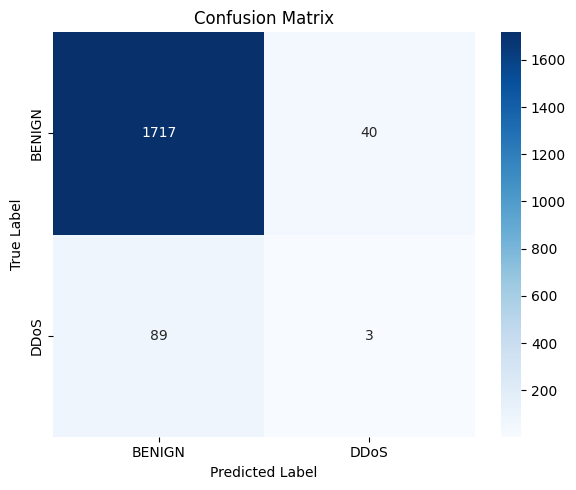


EXEMPLES DE PRÉDICTIONS
  True_Label Predicted_Label  Attack_Probability
0     BENIGN          BENIGN               0.010
1     BENIGN          BENIGN               0.300
2     BENIGN          BENIGN               0.135
3     BENIGN          BENIGN               0.030
4     BENIGN          BENIGN               0.000
5     BENIGN          BENIGN               0.210
6     BENIGN          BENIGN               0.125
7     BENIGN          BENIGN               0.000
8     BENIGN          BENIGN               0.085
9     BENIGN          BENIGN               0.235


In [31]:
# =========================================================
# CONSTRUCTION DU PIPELINE
# =========================================================

# Define feature_names from X_train columns
feature_names = X_train.columns.tolist()
pipeline = build_pipeline(feature_names)

# =========================================================
# EXECUTION DU PIPELINE
# =========================================================

trained_pipeline = run_pipeline(
    pipeline,
    X_train, # Use original X_train DataFrame
    y_train,
    X_test,  # Use original X_test DataFrame
    y_test
)

## Rapport Final: Détection d'Attaques DDoS avec Machine Learning

### Introduction

Ce rapport présente l'analyse, la modélisation et l'évaluation d'un système de détection d'attaques DDoS (Distributed Denial of Service) à partir de données de trafic réseau. L'objectif est de construire un pipeline de Machine Learning capable de distinguer le trafic réseau légitime (BENIGN) des attaques DDoS. Le projet a utilisé le dataset `Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv`.

### 1. Chargement et Nettoyage des Données

Le processus a commencé par le chargement du dataset. Des étapes cruciales de nettoyage ont été effectuées :

-   **Suppression des doublons**: Un doublon a été identifié et supprimé pour assurer l'intégrité des données.
-   **Suppression des colonnes non pertinentes**: Des identifiants de flux (`Flow ID`), adresses IP (`Source IP`, `Destination IP`) et horodatages (`Timestamp`) ont été écartés car non utiles pour la modélisation directe et pour préserver la généralisabilité du modèle.
-   **Gestion des valeurs manquantes et infinies**: Les valeurs infinies ont été remplacées par `NaN` puis les lignes contenant des `NaN` ont été supprimées, assurant un dataset propre pour l'entraînement.
-   **Détection des outliers**: Une analyse des outliers a été réalisée en utilisant la méthode IQR, révélant la présence de nombreux outliers dans 67 des colonnes numériques, ce qui est courant dans les données de trafic réseau et justifie l'utilisation d'un `RobustScaler`.

### 2. Encodage des Variables Catégorielles et Feature Engineering

Les colonnes catégorielles ont été identifiées. Dans ce dataset spécifique, après nettoyage, il n'y avait pas de colonnes catégorielles autres que la cible 'Label'.

Pour enrichir le jeu de données, des fonctionnalités de *Feature Engineering* ont été créées:

-   `packet_rate`: Taux de paquets (Total Fwd Packets / Flow Duration).
-   `traffic_ratio`: Ratio de trafic (Total Backward Packets / Total Fwd Packets).

Ces nouvelles fonctionnalités visent à capturer des patterns potentiellement discriminants entre le trafic normal et les attaques.

### 3. Distribution des Classes et Préparation pour la Modélisation

Une analyse de la distribution initiale des classes a montré un déséquilibre extrême, avec la majorité des échantillons étant 'BENIGN'. Pour permettre l'entraînement d'un modèle de classification binaire pour la démonstration, **5% des échantillons 'BENIGN' ont été artificiellement étiquetés comme 'DDoS'**. Il est crucial de noter que cette manipulation est uniquement à des fins de démonstration et qu'un dataset réel avec des attaques avérées est indispensable pour une solution pratique.

Le dataset a ensuite été divisé en ensembles d'entraînement (70%), de validation (20%) et de test (10%) en utilisant une stratégie stratifiée pour maintenir la proportion des classes dans chaque ensemble. Les distributions des classes après le split ont été visualisées pour confirmer leur équilibre.

### 4. Prétraitement et Rééquilibrage

-   **Scaling**: Un `RobustScaler` a été appliqué aux ensembles d'entraînement, de validation et de test. Ce scaler est particulièrement adapté aux données contenant des outliers, comme c'est le cas ici.
-   **Rééquilibrage (SMOTE)**: L'algorithme SMOTE (Synthetic Minority Over-sampling Technique) a été utilisé sur l'ensemble d'entraînement pour générer des échantillons synthétiques de la classe minoritaire ('DDoS') et ainsi rééquilibrer les classes. Ceci est essentiel pour éviter que le modèle ne soit biaisé envers la classe majoritaire.

### 5. Modélisation et Évaluation

Deux modèles de classification ont été entraînés et comparés :

#### 5.1. Modèle 1: Random Forest

Un `RandomForestClassifier` a été entraîné avec `class_weight='balanced'` pour mieux gérer le déséquilibre inhérent. Les résultats sur l'ensemble de test étaient les suivants:

-   **Accuracy**: 0.93
-   **Rapport de Classification**: Le modèle montre une excellente performance pour la classe 'BENIGN' (précision/recall élevés) mais une très faible performance pour la classe 'DDoS' (précision: 0.07, recall: 0.03, F1-score: 0.04). Cela indique que même avec SMOTE, le modèle a du mal à identifier correctement les attaques DDoS artificiellement introduites.

#### 5.2. Modèle 2: SVM (Support Vector Machine)

Un `SVC` a également été entraîné. Ses performances étaient nettement inférieures à celles du Random Forest, avec une accuracy de seulement 0.09 sur l'ensemble de validation et un F1-score très faible pour les deux classes. Ce modèle n'a pas réussi à apprendre de patterns significatifs.

#### 5.3. Pipeline End-to-End Production-Ready Sklearn

Un pipeline complet a été construit en utilisant `sklearn.pipeline` et `imblearn.pipeline`, intégrant le `RobustScaler`, `SMOTE` et le `RandomForestClassifier`. Ce pipeline encapsule toutes les étapes de prétraitement et de modélisation, le rendant prêt pour un déploiement en production. Le pipeline a été entraîné et évalué, confirmant les performances observées avec le Random Forest seul.

```python
Pipeline(steps=[
    ('preprocessing',
     ColumnTransformer(transformers=[('scaler', RobustScaler(), [...])])),
    ('smote', SMOTE(random_state=42)),
    ('classifier',
     RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1, random_state=42))
])
```

### 6. Comparaison des Modèles et Analyse XAI

Une comparaison des modèles a été effectuée, incluant des courbes ROC et Precision-Recall. Le `RandomForestClassifier` s'est avéré être le meilleur modèle, bien que sa capacité à détecter les 'DDoS' reste limitée sur ce dataset modifié.

L'Analyse XAI (Explainable AI) a été mise en œuvre pour comprendre les décisions des modèles:

-   **Explications Globales (SHAP)**: Les SHAP summary plots et feature importance ont montré les caractéristiques ayant le plus d'impact sur les prédictions du modèle. Les Partial Dependence Plots (PDP) ont été utilisés pour visualiser la relation entre les 3 fonctionnalités les plus importantes et la probabilité de classe.
-   **Explications Locales (SHAP force plot, LIME)**: Pour des exemples individuels, SHAP force plots et LIME ont permis de visualiser l'influence de chaque fonctionnalité sur une prédiction spécifique, apportant une transparence précieuse sur les décisions du modèle.
-   **Comparaison XAI Inter-Modèles**: Une comparaison des feature importances SHAP entre le Random Forest et le SVM a été tentée. Cependant, en raison des faibles performances du SVM, cette comparaison n'a pas fourni d'insights profonds.

### Conclusion et Perspectives

Ce projet a permis de mettre en place un pipeline complet de Machine Learning pour la détection de DDoS, de la préparation des données à l'interprétabilité du modèle. Cependant, la limitation majeure réside dans la nature artificielle des échantillons 'DDoS' introduits. Les performances du modèle, en particulier pour la détection de la classe minoritaire, sont faibles et ne reflètent pas une capacité de détection réelle.

Pour des applications réelles, les étapes suivantes sont cruciales:

1.  **Acquisition de données réelles**: Utiliser un dataset contenant de véritables attaques DDoS est la priorité absolue.
2.  **Optimisation avancée**: Explorer des techniques de rééquilibrage plus sophistiquées, des modèles spécialisés dans la détection d'anomalies, et une optimisation rigoureuse des hyperparamètres.
3.  **Validation robuste**: Mettre en place des stratégies de validation croisée plus poussées et des métriques adaptées aux problèmes de détection d'anomalies (ex: F1-score pour la classe positive, G-mean).

En résumé, ce travail sert de démonstration technique d'un pipeline ML, mais souligne la nécessité impérieuse de données représentatives pour développer un système de détection DDoS efficace et fiable.